## Import necessary library

In [15]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from util.parse_loc import parse_forecast_file

## Load The DataFrame from the models forecasted folder

In [16]:
forecast_folder = Path("forecast_price") / "LSTM"

crops = {
    "Cassava": "cassava_forecast.txt",
    "Corn": "corn_forecast.txt",
    "Green Bean": "green_bean_forecast.txt",
    "Soybean": "soybean_forecast.txt",
}

In [17]:
crop_data = {}

for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)

    if os.path.exists(file_path):
        dates, prices = parse_forecast_file(file_path)
        crop_data[crop_name] = {"dates": dates, "prices": prices}
        print(f"Loaded {crop_name} data: {len(prices)} price points")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nLoaded data for {len(crop_data)} crops")

crop_price_avg = {}

for crop_name, data in crop_data.items():
    dates = data["dates"]
    prices = data["prices"]

    if len(prices) > 0:
        avg_price = np.round(np.mean(prices), 2)
        crop_price_avg[crop_name] = avg_price
        print(f"{crop_name} average price: {avg_price:.2f}")
    else:
        print(f"No price data available for {crop_name}")


Loaded Cassava data: 12 price points
Loaded Corn data: 12 price points
Loaded Green Bean data: 12 price points
Loaded Soybean data: 12 price points

Loaded data for 4 crops
Cassava average price: 2.98
Corn average price: 11.08
Green Bean average price: 25.47
Soybean average price: 18.06


## Normalized the data for each crops

In [18]:
for crop_name, data in crop_data.items():
    new_data_lst = []

    # Access the 'prices' list from the data dictionary
    for price in data["prices"]:
        if price != 0:
            new_data_lst.append(price / float(crop_price_avg[crop_name]))

    # Update the prices with normalized values
    crop_data[crop_name]["prices"] = new_data_lst

In [19]:
def find_intersections(dates1, prices1, dates2, prices2):
    """
    Find intersection points between two price curves
    """
    intersections = []

    # Find common dates between the two datasets
    common_dates = []
    common_prices1 = []
    common_prices2 = []

    for i, date1 in enumerate(dates1):
        if date1 in dates2:
            j = dates2.index(date1)
            common_dates.append(date1)
            common_prices1.append(prices1[i])
            common_prices2.append(prices2[j])

    # Find sign changes in price differences (indicates intersection)
    for i in range(len(common_prices1) - 1):
        diff1 = common_prices1[i] - common_prices2[i]
        diff2 = common_prices1[i + 1] - common_prices2[i + 1]

        # Check if there's a sign change (intersection)
        if diff1 * diff2 < 0:
            # Linear interpolation to find exact intersection point
            t = abs(diff1) / (abs(diff1) + abs(diff2))
            intersect_date = (
                common_dates[i] + (common_dates[i + 1] - common_dates[i]) * t
            )
            intersect_price = (
                common_prices1[i] + (common_prices1[i + 1] - common_prices1[i]) * t
            )

            intersections.append((intersect_date, intersect_price))

    return intersections

In [20]:
# Configuration and styling
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fill_colors = colors
line_styles = ["-"] * 4


def calculate_statistics(crop_data):
    """Calculate comprehensive statistics for all crops"""
    all_prices = []
    for data in crop_data.values():
        all_prices.extend(data["prices"])

    stats = {
        "avg_normalized": np.mean(all_prices),
        "std_normalized": np.std(all_prices),
        "num_crops": len(crop_data),
    }
    return stats, all_prices


def plot_crop_lines(ax, crop_data, colors, fill_colors):
    """Plot crop price lines with fill areas"""
    for i, (crop_name, data) in enumerate(crop_data.items()):
        # Convert datetime to integer indices for consistent plotting
        date_indices = list(range(len(data["dates"])))

        ax.plot(
            date_indices,
            data["prices"],
            color=colors[i],
            linewidth=2.5,
            linestyle="-",
            label=crop_name,
            alpha=0.9,
        )
        # Fill between removed to eliminate fill color under the graphs


def find_peak_prices(crop_data):
    """Find the local peak price for each crop"""
    peak_prices = {}

    for crop_name, data in crop_data.items():
        if data["prices"]:
            # Find the maximum price and its index
            peak_price = max(data["prices"])
            peak_index = data["prices"].index(peak_price)
            peak_date = data["dates"][peak_index]

            peak_prices[crop_name] = {
                "price": peak_price,
                "date": peak_date,
                "index": peak_index,
            }

    return peak_prices


def style_plot(ax, title, xlabel, ylabel):
    """Apply consistent styling to plot"""
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(
        loc="upper right",
    )
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

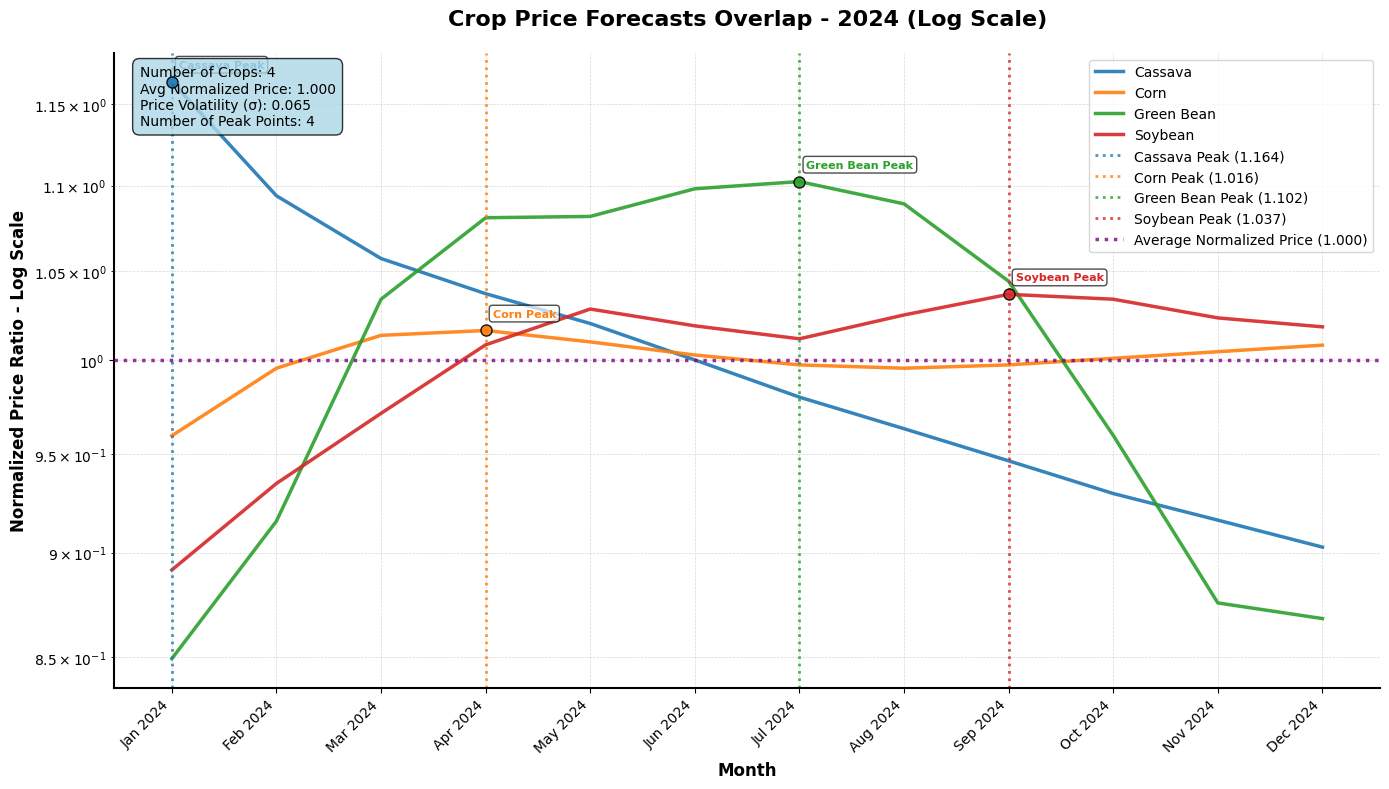

In [21]:
# Main plotting function
def create_crop_analysis_plot():
    """Create comprehensive crop price analysis plot"""
    stats, all_prices = calculate_statistics(crop_data)

    plt.figure(figsize=(14, 8))
    ax = plt.gca()

    # Plot crop lines and fill areas
    plot_crop_lines(ax, crop_data, colors, fill_colors)

    # Find peak prices for each crop
    peak_prices = find_peak_prices(crop_data)

    # Plot vertical dotted lines at each crop's peak date
    for i, (crop_name, peak_info) in enumerate(peak_prices.items()):
        peak_price = peak_info["price"]
        peak_index = peak_info["index"]
        peak_date = peak_info["date"]

        # Add vertical dotted line at peak date
        ax.axvline(
            x=peak_index,
            color=colors[i],
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label=f"{crop_name} Peak ({peak_price:.3f})",
        )

        # Add a marker at the peak point
        ax.plot(
            peak_index,
            peak_price,
            "o",
            markersize=8,
            markerfacecolor=colors[i],
            markeredgecolor="black",
            zorder=10,
            alpha=0.9,
        )

        # Add annotation for the peak point
        ax.annotate(
            f"{crop_name} Peak",
            (peak_index, peak_price),
            xytext=(5, 10),
            textcoords="offset points",
            fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7),
            color=colors[i],
            fontweight="bold",
        )

    # Add average price line
    avg_price = stats["avg_normalized"]
    ax.axhline(
        y=avg_price,
        color="purple",
        linestyle=":",
        linewidth=2.5,
        label=f"Average Normalized Price ({avg_price:.3f})",
        alpha=0.8,
        zorder=5,
    )

    # Set log scale and styling
    ax.set_yscale("log")
    style_plot(
        ax,
        "Crop Price Forecasts Overlap - 2024 (Log Scale)",
        "Month",
        "Normalized Price Ratio - Log Scale",
    )

    # Create a list of all dates from one of the crop datasets (assuming all have same dates)
    example_crop = list(crop_data.keys())[0]
    all_dates = crop_data[example_crop]["dates"]

    # Format the dates as month names
    month_labels = [d.strftime("%b %Y") for d in all_dates]

    # Set the x-ticks to be at the date positions
    ax.set_xticks(range(len(all_dates)))
    ax.set_xticklabels(month_labels)

    # Add statistics text box
    stats_text = (
        f"Number of Crops: {stats['num_crops']}\n"
        f"Avg Normalized Price: {stats['avg_normalized']:.3f}\n"
        f"Price Volatility (σ): {stats['std_normalized']:.3f}\n"
        f"Number of Peak Points: {len(peak_prices)}"
    )

    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="lightblue",
            alpha=0.8,
            edgecolor="black",
        ),
    )

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return peak_prices


peak_prices = create_crop_analysis_plot()